# Thesis: Reclaimed Timber in Deep Generative Design

**Notebook:** c25_26_27_optimizer_workflow_with_cost_and_ILP  
**Author:** Jasper Cluistra     
**Last Updated:** 2026-02-27

## Cost and ILP Optimization Workflow

Generate a cost matrix for the geometry using timber datasets, then use ILP to find the best assignments.

**Inputs:** CSV timber dataset, Digital geometry  
**Outputs:** Best match for each structural element

# IMPORTING

In [4]:
import config
import json
import pandas as pd

file_path = config.TIMBER_STOCK_PATH / 'complete_timber.csv'
json_path = config.DATA_IO_PATH / "search_space.json"

with open(json_path, "r") as f:
    optimizer_search_space = json.load(f)

print(f"Search space loaded. The optimizer can control {len(optimizer_search_space)} parameters.")

# Try common combinations
read_attempts = [
    {"sep": ",", "encoding": "utf-8"},
    {"sep": ";", "encoding": "utf-8"},
    {"sep": ",", "encoding": "latin1"},
    {"sep": ";", "encoding": "latin1"},
]

df_input_stock = None
for opts in read_attempts:
    try:
        df_try = pd.read_csv(file_path, **opts)  # type: ignore
        # Valid if we get more than 1 column
        if df_try.shape[1] > 1:
            df_input_stock = df_try
            print(f"Loaded with sep='{opts['sep']}' and encoding='{opts['encoding']}'")
            break
    except Exception:
        pass

if df_input_stock is None:
    raise ValueError("Could not parse CSV with tested delimiter/encoding combinations.")

# Clean column names
df_input_stock.columns = df_input_stock.columns.str.strip()

print("Detected columns:", df_input_stock.columns.tolist())
print(f"\nDataset contains {df_input_stock.shape[0]} elements\n")
display(df_input_stock.head())

Search space loaded. The optimizer can control 18 parameters.
Loaded with sep=';' and encoding='utf-8'
Detected columns: ['Member_ID', 'State', 'Length', 'Depth', 'Width', 'f_mk', 'f_tk', 'E_modulus_eff', 'E_modulus_005', 'f_vk', 'f_c0k', 'k_density', 'mean_density', 'ECC', 'Origin_Country', 'Transport_Dist', 'EmissionFactor', 'ProcessingFactor']

Dataset contains 480 elements



,Member_ID,State,Length,Depth,Width,f_mk,f_tk,E_modulus_eff,E_modulus_005,f_vk,f_c0k,k_density,mean_density,ECC,Origin_Country,Transport_Dist,EmissionFactor,ProcessingFactor
0,NS_00000,0,1450.0,100.0,38.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Baltic States,1558.51,0.1765,0
1,NS_00001,0,1450.0,100.0,50.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,France,462.42,0.1726,0
2,NS_00002,0,1450.0,100.0,63.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Germany,335.57,0.1749,0
3,NS_00003,0,1450.0,100.0,75.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Sweden,1095.34,0.1750,0
4,NS_00004,0,1450.0,100.0,100.0,24.0,14.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Sweden,1002.80,0.1770,0


# GEOMETRY

parameters loaded from c:\Users\jaspe\Documents\PyRepo\thesis_generative_timber\c11_params.py
GRID: 2x2, EDGE_LENGTH: 3.0, LAYER_HEIGHT: 1.5, DIVISIONS: 8, NUM_SAMPLES: 20000

Geometry: 13 nodes, 32 members
Length range [m]: 1.875 - 4.142


,edge_id,V1,V2,length_m
0,e0,0,1,4.125
1,e1,0,3,4.125
2,e2,1,2,1.875
3,e3,1,4,3.750
4,e4,2,5,3.000


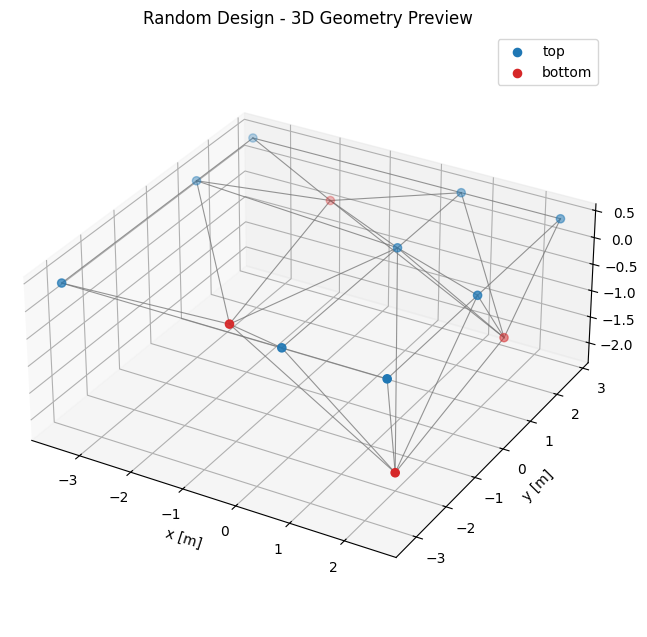

In [5]:
import importlib
import matplotlib.pyplot as plt
import c23_stage_geometry as stage_geometry

importlib.reload(stage_geometry)

geometry_out = stage_geometry.run_random_geometry_stage(
    json_path=json_path if "json_path" in globals() else None,
    optimizer_search_space=optimizer_search_space if "optimizer_search_space" in globals() else None,
    sample_id=0,
)

my_random_design = geometry_out["my_random_design"]
vertices_list = geometry_out["vertices_list"]
df_vertices = geometry_out["df_vertices"]
df_edges = geometry_out["df_edges"]
df_geometry_overview = geometry_out["df_geometry_overview"]

print(f"Geometry: {len(df_vertices)} nodes, {len(df_edges)} members")
print(
    f"Length range [m]: {df_geometry_overview['length_m'].min():.3f}"
    f" - {df_geometry_overview['length_m'].max():.3f}"
)
display(df_geometry_overview[["edge_id", "V1", "V2", "length_m"]].head(5))

fig, ax = stage_geometry.plot_geometry_preview(
    df_vertices=df_vertices,
    df_edges=df_edges,
    figsize=(8, 7),
)
plt.show()

# STRUCTURAL BASE

In [10]:
import importlib
import config
import c25_structural_check as structural_check
from workflows import c25_stage_structural as stage_structural

importlib.reload(structural_check)
importlib.reload(stage_structural)
print(f"Using structural module: {stage_structural.__file__}")

# Optional explicit prefix. Set to None to auto-resolve latest valid bundle when surrogate mode is used.
MODEL_PREFIX = "ID20260418_215020_LR0.0005_EP100_R0.99_F6"

# Single orchestrated call for the structural stage.
# Demand-only mode keeps c25 independent from section area assignment.
_structural_ns = stage_structural.run_structural_stage_notebook(
    df_input_stock=df_input_stock if "df_input_stock" in globals() else None,
    df_vertices=df_vertices if "df_vertices" in globals() else None,
    df_edges=df_edges if "df_edges" in globals() else None,
    model_prefix=MODEL_PREFIX if "MODEL_PREFIX" in globals() else None,
    bundle=SURROGATE_BUNDLE if "SURROGATE_BUNDLE" in globals() else None,
    gnn_margin=1.10,
    force_mode="demand-only",
    export_slots_path=config.EXPORT_PATH / "structure_slots.csv",
    verbose=True,
)

# Publish outputs for downstream notebook stages.
globals().update(_structural_ns)

print("Structural stage outputs:", ", ".join(sorted(_structural_ns.keys())))
summary = _structural_ns.get("summary")
if isinstance(summary, dict):
    print("Structural summary:")
    for key, value in summary.items():
        print(f"  {key}: {value}")
elif summary is not None:
    print("Structural summary:")
    print(summary)
else:
    print("Structural summary: none returned")

Using structural module: c:\Users\jaspe\Documents\PyRepo\thesis_generative_timber\workflows\c25_stage_structural.py
Demand-only structural mode active (no surrogate force prediction in c25).
Force source: demand-only
Utilization: 32 members, 480 stock -> 0 safe combinations
Structural stage outputs: SURROGATE_BUNDLE, SURROGATE_BUNDLE_ERROR, df_forces, df_forces_local, df_inventory, df_slots, df_utilization_long, df_utilization_matrix, df_utilization_matrix_display, forces_source, safe_options, structural_out, summary
Structural summary:
  members: 32
  stock_items: 480
  safe_combinations: 0


# COST, MATCHING AND FITNESS

In [11]:
import importlib
import pandas as pd
import config
from workflows import c26_stage_cost_matrix as stage_cost
from workflows import c27_stage_milp as stage_milp
from workflows import c24_stage_fitness as stage_fitness

importlib.reload(stage_cost)
importlib.reload(stage_milp)
importlib.reload(stage_fitness)

# -------------------------------
# STEP 1: COST MATRIX STAGE
# -------------------------------
target_slot_for_analysis = "e24"
utilization_threshold = 1.00
utilization_threshold_sweep = [1.00, 1.25, 1.50]
utilization_matrix_for_cost = df_utilization_matrix if "df_utilization_matrix" in globals() else None

# Candidate-level surrogate context for c26 (used when no external utilization matrix is provided).
surrogate_context_for_cost = {
    "df_vertices": df_vertices if "df_vertices" in globals() else None,
    "df_edges": df_edges if "df_edges" in globals() else None,
    "bundle": SURROGATE_BUNDLE if "SURROGATE_BUNDLE" in globals() else None,
    "model_prefix": MODEL_PREFIX if "MODEL_PREFIX" in globals() else None,
}

cost_out = stage_cost.run_cost_matrix_stage(
    df_slots=df_slots,
    df_input_stock=df_input_stock,
    df_utilization_matrix=utilization_matrix_for_cost,
    utilization_threshold=utilization_threshold,
    target_stock_ids=df_input_stock["Member_ID"].dropna().astype(str).tolist(),
    export_cost_matrix_path=config.EXPORT_PATH / "final_cost_matrix.csv",
    include_threshold_sweep=True,
    utilization_threshold_sweep=utilization_threshold_sweep,
    export_slot_analysis=True,
    target_slot_for_analysis=target_slot_for_analysis,
    export_dir=config.EXPORT_PATH,
    quiet=True,
    surrogate_context=surrogate_context_for_cost,
 )

cost_matrix = cost_out["cost_matrix"]
enriched_stock = cost_out["enriched_stock"]
df_logs = cost_out["df_logs"]
df_cost_matrix_display = cost_out["df_cost_matrix_display"]
df_threshold_sweep = cost_out["df_threshold_sweep"]
slot_analysis = cost_out["slot_analysis"]
cost_summary = cost_out["summary"]

print(
    f"Cost matrix: {cost_summary['slots']} slots x {cost_summary['stock_items']} stock, "
    f"valid={cost_summary['valid_pairs']}/{cost_summary['total_pairs']} "
    f"(pruned={cost_summary.get('pruned_pairs', 0)}), "
    f"utilization_mode={cost_summary.get('utilization_mode', 'unknown')}"
 )

if df_threshold_sweep is not None and len(df_threshold_sweep) > 0:
    print("Threshold sweep summary:")
    display(df_threshold_sweep)

if slot_analysis is not None:
    print(f"Detailed slot analysis exported: {slot_analysis['analysis_export_path']}")

# -------------------------------
# STEP 2: MILP STAGE
# -------------------------------
print("Starting MILP optimizer...")
milp_out = stage_milp.run_milp_stage(
    cost_matrix=cost_matrix,
    enriched_stock=enriched_stock,
    df_slots=df_slots,
    reclaimed_marker="RS",
    new_marker="NS",
    solver_msg=False,
    raise_on_infeasible_slots=True,
 )

status = milp_out["status"]
df_results = milp_out["df_results"]
total_cost = milp_out["total_cost"]
milp_summary = milp_out["summary"]

print(
    f"MILP setup: {milp_summary['reclaimed_items']} reclaimed + "
    f"{milp_summary['new_items']} new stock items for {milp_summary['slots']} slots"
 )
print(f"MILP status: {status}")
print(f"Total assignment cost: {total_cost:.2f}")
if len(df_results) > 0:
    display(df_results.head(10))

# -------------------------------
# STEP 3: FITNESS STAGE
# -------------------------------
fitness_out = stage_fitness.run_fitness_stage(
    df_results=df_results,
    total_cost=total_cost,
    status=status,
    export_fitness_json_path=config.EXPORT_PATH / "fitness_result.json",
    export_fitness_csv_path=config.EXPORT_PATH / "fitness_result.csv",
 )

fitness_result = fitness_out["fitness_result"]
print("Fitness summary:")
print(f"  objective: {fitness_result.get('objective', 'n/a')}")
print(f"  feasible: {fitness_result.get('is_feasible', 'n/a')}")

ValueError: df_edges must include a real baseline area column (Area/cross_section_area/A) when surrogate_context is provided.

In [ ]:
# Verify dimension columns exist
inv_dims = [col for col in df_input_stock.columns if col.lower() in ['width', 'depth', 'length']]
slot_reqs = [col for col in df_slots.columns if 'Req' in col]
print(f"Inventory dims: {inv_dims} | Slot reqs: {slot_reqs}")

# EXPORT

Exports structural parameters (vertices + edges with assigned timber) for Grasshopper reconstruction.

In [ ]:
# Export geometry + matching results
import pandas as pd
import config

EXPORT_PREFIX = "optimum"
required_vars = ["df_vertices", "df_edges", "df_results"]
if any(name not in globals() for name in required_vars):
    raise ValueError(f"Missing: {', '.join(required_vars)}")

df_edges_export = pd.merge(df_edges, df_results[["edge_id", "assigned_timber", "CO2_Penalty"]], on="edge_id", how="left")
df_edges_export["assigned_timber"] = df_edges_export["assigned_timber"].fillna("UNASSIGNED")
df_edges_export["CO2_Penalty"] = df_edges_export["CO2_Penalty"].fillna(0)

df_vertices.to_csv(config.EXPORT_PATH / f"{EXPORT_PREFIX}_vertices.csv", index=False)
df_edges_export.to_csv(config.EXPORT_PATH / f"{EXPORT_PREFIX}_edges_with_stock.csv", index=False)
n_matched = int((df_edges_export["assigned_timber"] != "UNASSIGNED").sum())
print(f"Exported: {len(df_vertices)} vertices, {len(df_edges_export)} edges ({n_matched} matched)")

# LITERATURE

### COST MATRIX
We now use one universal assignment formula for both reclaimed and new timber in the same cost matrix:

$$C_{i,j} = E_{embodied,i} + E_{prep,i} + E_{trans,i,j} + E_{waste,i,j} + E_{saw,i,j}$$

With:
- $E_{embodied,i} = V_{stock,i} \cdot M_{material,i}$ (from `ECC` in stock data)
- $E_{prep,i} = V_{stock,i} \cdot E_{prep}$
- $E_{trans,i,j} = \left(\frac{(V_{req}+V_{over})\cdot\rho}{1000}\right)\cdot D\cdot F_{trans}$
- $E_{waste,i,j} = V_{waste} \cdot E_{EoL}$
- $E_{saw,i,j} = P_{cut}$ when cutting is required, else 0

Interpretation by timber type:
- New timber: typically high `ECC`, usually low/zero preparation factor
- Reclaimed timber: `ECC` near 0, non-zero preparation factor

### MATCHING ALGORITHM / MILP
The assignment problem in this notebook is solved as a mixed-integer linear program (MILP). Let:

- $I$ be the set of required structural slots,
- $J$ be the set of inventory stock elements,
- $F \subseteq I \times J$ be the set of physically feasible slot-stock combinations,
- $R \subseteq J$ be the subset of reclaimed timber,
- $N \subseteq J$ be the subset of new timber,
- $c_{ij}$ be the cost of assigning stock element $j$ to slot $i$,
- $x_{ij} \in \{0,1\}$ be the decision variable, where $x_{ij}=1$ means that stock element $j$ is assigned to slot $i$.

$$
\min_{x} \sum_{(i,j) \in F} c_{ij} x_{ij}
$$

subject to

$$
\sum_{j:(i,j)\in F} x_{ij} = 1 \qquad \forall i \in I
$$

$$
\sum_{i:(i,j)\in F} x_{ij} \le 1 \qquad \forall j \in R
$$

$$
\sum_{i:(i,j)\in F} x_{ij} \le |I| \qquad \forall j \in N
$$

$$
x_{ij} = 0 \qquad \forall (i,j) \notin F
$$

In words: every structural member must receive exactly one feasible timber element, reclaimed timber can be used at most once, and new timber can be reused when physically feasible.

### MULTI-OBJECTIVE FITNESS FUNCTION

The fitness function balances three competing objectives:

$$F(\mathbf{x}) = \omega_1 \left( \frac{f_{inner}^*(\mathbf{x})}{\mathcal{C}_{max}} \right) - \omega_2 \left( \frac{\mathcal{R}(\mathbf{x}, \mathbf{y}^*)}{\mathcal{R}_{max}} \right) + \omega_3 \left( \frac{\mathcal{W}(\mathbf{x}, \mathbf{y}^*)}{\mathcal{W}_{max}} \right)$$

- **$f_{inner}^*$**: MILP cost (kg CO2e) — penalizes virgin material and waste
- **$\mathcal{R}$**: Reuse rate (%) — reward for using reclaimed timber (subtracted, so higher reuse = better)
- **$\mathcal{W}$**: Total waste (m³) — penalizes inefficient cutting
- **$\omega_i$**: Weight coefficients to tune priorities

All metrics are normalized to [0, 1] using precomputed dataset-driven extremes ($\mathcal{C}_{max}$, $\mathcal{R}_{max}$, $\mathcal{W}_{max}$).

**Design philosophy**: The MILP cost matrix already accounts for all physical and geometric infeasibilities (by returning ∞ for impossible assignments). This means the upper-level fitness function does NOT need a conditional fallback loop. Instead, we can directly minimize a weighted multi-objective sum.

**Sign convention**:
- Positive coefficient on cost: higher MILP cost → higher (worse) fitness
- Negative coefficient on reuse: higher reuse rate → lower (better) fitness ✓
- Positive coefficient on waste: higher waste → higher (worse) fitness

**Typical design trade-offs**:
- High ω₁ (cost weight): prioritize LCA minimization across all materials
- High ω₂ (reuse weight): prioritize reclaimed material recovery
- High ω₃ (waste weight): prioritize cutting efficiency